In [27]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt

In [10]:
dataset_path = "../data/PDF_stoxx600"
dataset_path_texts = "../data/TEXT_stoxx600_docling"

In [25]:
reports_path = glob.glob(os.path.join(dataset_path_texts, "*.txt"))
reports = list(map(lambda x: x.split("/")[-1], reports_path))
len(reports)

215

In [29]:
nace_classes = pd.read_excel(os.path.join(dataset_path, "STOXX600_as_of_2025_03_13.xlsx"))

In [31]:
nace_classes = nace_classes[nace_classes.apply(lambda x: str(x["Report"])[:-4] + ".txt" in reports, axis=1)]
nace_classes.head()

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report
3,Banco de Sabadell SA,SAB-ES,SAB-ES,6927.920000,10467.899000,11656.548000,64.19,K,Banco de Sabadell SA1.pdf
5,Gerresheimer AG,GXI-DE,GXI-DE,1817.094000,1990.486000,2035.903000,22.22,C,Gerresheimer AG1.pdf
6,TUI AG,TUI1-DE,TUI1-DE,16544.900000,20665.900000,23167.300000,79.12,N,TUI AG1.pdf
7,InterContinental Hotels Group PLC,IHG-GB,IHG-GB,3703.230315,4277.063406,4551.208304,55.10,I,InterContinental Hotels Group PLC1.pdf
9,LEG Immobilien SE,LEG-DE,LEG-DE,1171.100000,1289.800000,NaN,68.32,L,LEG Immobilien SE1.pdf


In [39]:
nace_classes.groupby("NACE_letter").count()

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,Report
NACE_letter,,,,,,,,
A,2,2,2,2,2,2,2,2
B,4,4,4,4,4,4,4,4
C,95,95,95,95,95,81,95,95
D,7,7,7,7,7,2,7,7
E,4,4,4,4,4,1,4,4
F,4,4,4,4,4,2,4,4
G,11,11,11,11,11,4,11,11
H,4,4,4,4,4,3,4,4
I,3,3,3,3,3,3,3,3


<BarContainer object of 16 artists>

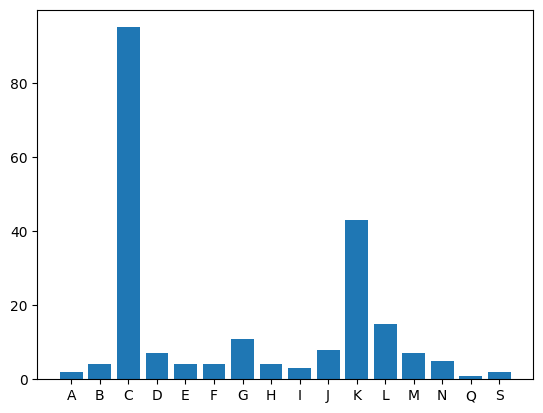

In [38]:
plt.bar(nace_classes.groupby("NACE_letter").count().index, nace_classes.groupby("NACE_letter").count()["Name"])